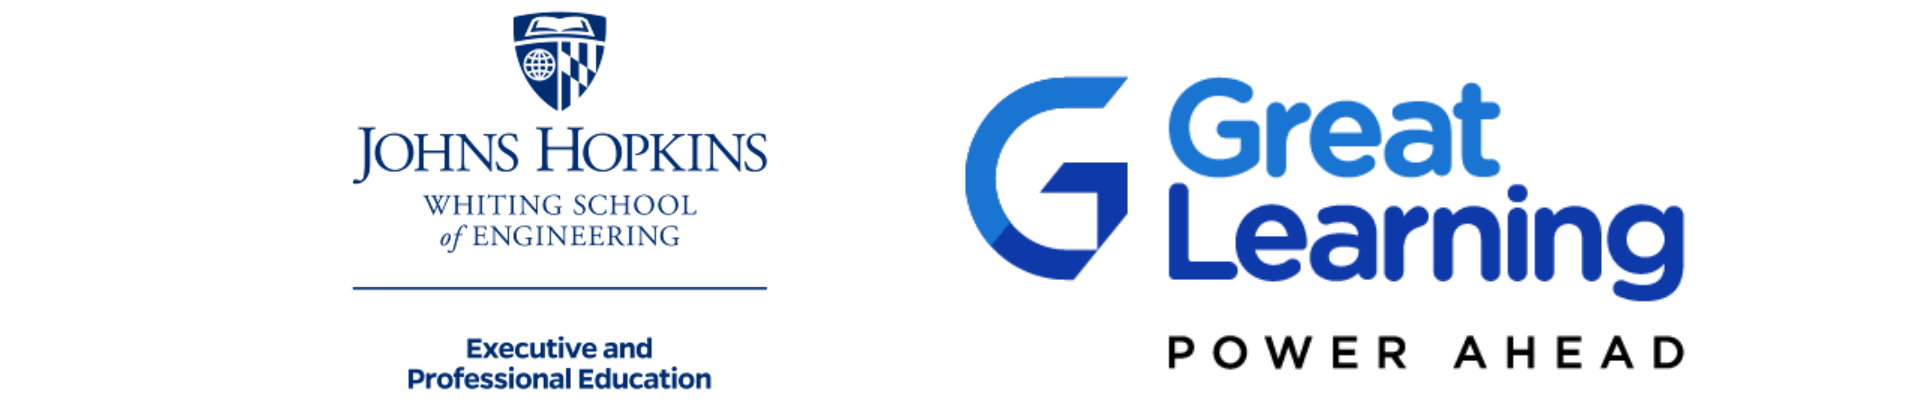

# Agentic Human Behavior Lab: ABM + LLM-driven Compliance

This notebook combines:

- A simple **agent-based epidemic simulation** (agents move through places and transmit infection)
- A lightweight **SEIR mental model** to interpret dynamics (Susceptible → Exposed → Infectious → Recovered)
- An **LLM-driven compliance gate** that decides whether a requested run / analysis is allowed under a policy pack,
  and (when allowed) returns a **machine-readable rerun plan** that can be executed against the simulation functions.

## Why SEIR here?

The simulation is *agent-based* (explicit agents, schedules, places), but many outputs are easier to explain
with SEIR-style intuition: infections rise when effective contact rate is high, then fall as recovery accumulates
and susceptible population shrinks.

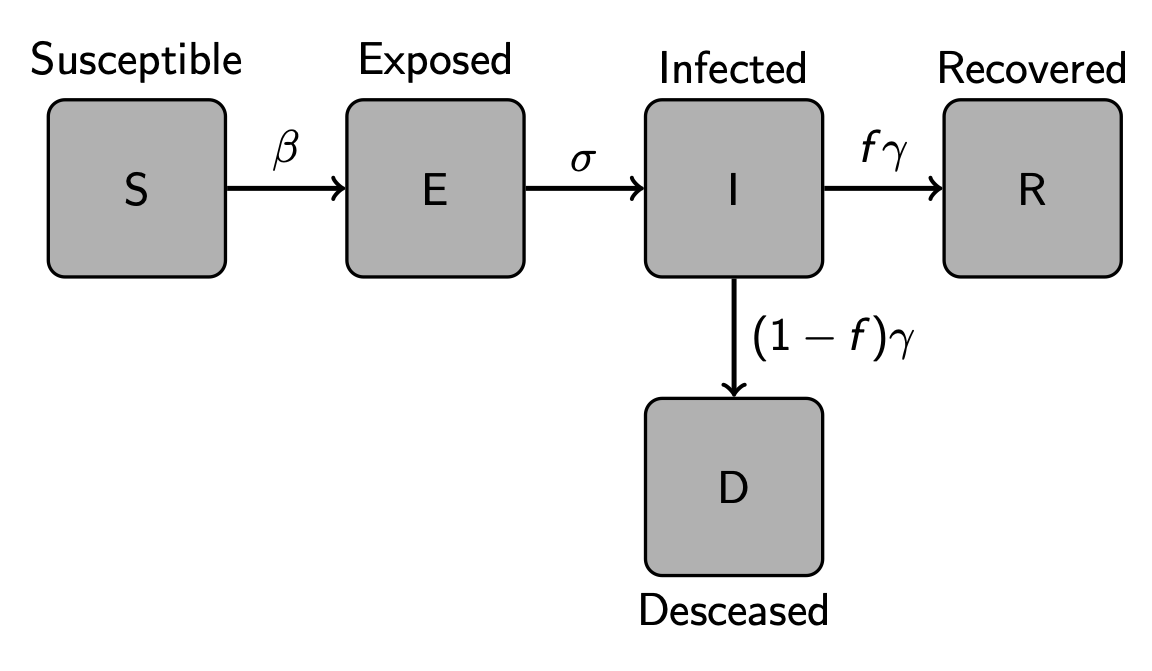

## What you'll do

1. Define agents, places, and schedules.
2. Run baseline and intervention scenarios (masks, capacity limits, closures, staggered work).
3. Compare outcomes with simple summary metrics (peak infections, attack rate).
4. Use the compliance layer to:
   - determine which policies apply,
   - decide ALLOW / BLOCK / REDACT / ESCALATE,
   - produce a rerun plan for the scenarios/parameters to execute.

## What the compliance layer returns

For each user request, the LLM returns a structured `ComplianceDecision` with:

- `decision`: **ALLOW / BLOCK / REDACT / ESCALATE**
- `applicable_policies`: which policy packs triggered the decision
- `rerun_plan`: (optional) a structured plan describing **which scenarios to rerun** and **what parameters/policy knobs to override**


## 0) Timestamped run directory & logging

In [ ]:
import os, time, json, math, random, csv
from dataclasses import dataclass, field
from typing import List, Dict, Any, Optional, Tuple
from pathlib import Path

TS = time.strftime('%Y%m%d_%H%M%S')
RUN_DIR = Path.cwd() / f'human_agentic_runs/{TS}'
RUN_DIR.mkdir(parents=True, exist_ok=True)
LOG_PATH = RUN_DIR / 'runs.jsonl'
EXPORT_DIR = RUN_DIR / 'exports'
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

seed = 42
random.seed(seed)

print('Run dir:', RUN_DIR)

Run dir: /content/human_agentic_runs/20260111_161118


## 1) World model: grid, POIs, agent archetypes

In [ ]:
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple
import random
import matplotlib.pyplot as plt


@dataclass
class POI:
    id: str
    kind: str  # home, work, school, retail, park
    x: int
    y: int
    capacity: int = 50
    open_start: int = 7   # hour
    open_end: int = 22

@dataclass
class Agent:
    id: int
    archetype: str  # worker, student, retiree
    home: str
    work_or_school: Optional[str] = None
    compliance: float = 0.8  # likelihood to follow policy
    infected: bool = False
    recovered: bool = False

GRID_W, GRID_H = 12, 12

# Build minimal city
POIS: Dict[str, POI] = {}
# Homes
for i in range(30):
    POIS[f'H{i}'] = POI(id=f'H{i}', kind='home', x=random.randint(0,GRID_W-1), y=random.randint(0,GRID_H-1), capacity=5)
# Workplaces
for i in range(6):
    POIS[f'W{i}'] = POI(id=f'W{i}', kind='work', x=random.randint(0,GRID_W-1), y=random.randint(0,GRID_H-1), capacity=40, open_start=8, open_end=18)
# Schools
for i in range(4):
    POIS[f'S{i}'] = POI(id=f'S{i}', kind='school', x=random.randint(0,GRID_W-1), y=random.randint(0,GRID_H-1), capacity=60, open_start=8, open_end=15)
# Retail/parks
for i in range(6):
    POIS[f'R{i}'] = POI(id=f'R{i}', kind='retail', x=random.randint(0,GRID_W-1), y=random.randint(0,GRID_H-1), capacity=30, open_start=10, open_end=21)
for i in range(3):
    POIS[f'P{i}'] = POI(id=f'P{i}', kind='park', x=random.randint(0,GRID_W-1), y=random.randint(0,GRID_H-1), capacity=80, open_start=6, open_end=22)

# Agents
AGENTS: List[Agent] = []
AID = 0
for _ in range(40):
    home = random.choice([k for k,v in POIS.items() if v.kind=='home']).strip()
    work = random.choice([k for k,v in POIS.items() if v.kind=='work']).strip()
    AGENTS.append(Agent(id=AID, archetype='worker', home=home, work_or_school=work, compliance=random.uniform(0.5,1.0)))
    AID+=1
for _ in range(40):
    home = random.choice([k for k,v in POIS.items() if v.kind=='home']).strip()
    school = random.choice([k for k,v in POIS.items() if v.kind=='school']).strip()
    AGENTS.append(Agent(id=AID, archetype='student', home=home, work_or_school=school, compliance=random.uniform(0.5,1.0)))
    AID+=1
for _ in range(20):
    home = random.choice([k for k,v in POIS.items() if v.kind=='home']).strip()
    AGENTS.append(Agent(id=AID, archetype='retiree', home=home, work_or_school=None, compliance=random.uniform(0.5,1.0)))
    AID+=1

len(AGENTS), len(POIS)

(100, 49)

In [ ]:
# Let's look at our landscape along with our Points of Interest
def plot_pois(pois):
    """
    Display Points of Interest (POIs) on a 2D grid.
    Assumes each POI has attributes: x, y, kind.
    """
    kind_colors = {
        "home": "tab:blue",
        "work": "tab:orange",
        "school": "tab:green",
        "leisure": "tab:red",
    }

    plt.figure(figsize=(6, 6))

    for key, poi in pois.items():
        color = kind_colors.get(poi.kind, "gray")
        plt.scatter(poi.x, poi.y, c=color, s=80, alpha=0.8)
        plt.text(poi.x + 0.02, poi.y + 0.02, poi.kind, fontsize=8)

    plt.title("Points of Interest (POIs)")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.grid(True, alpha=0.3)
    plt.axis("equal")
    plt.show()

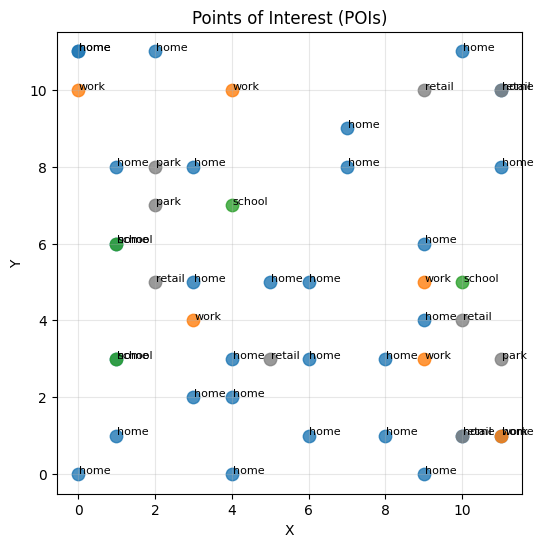

In [ ]:
plot_pois(POIS)

In [ ]:
# Let's look at a few of our agents and how they're assigned
indexes = [0, 2, 43, 45, 91, 97]

display(list(map(lambda i: AGENTS[i], indexes)))

[Agent(id=0, archetype='worker', home='H12', work_or_school='W2', compliance=0.9947616753182976, infected=False, recovered=False),
 Agent(id=2, archetype='worker', home='H21', work_or_school='W2', compliance=0.9214259600949049, infected=False, recovered=False),
 Agent(id=43, archetype='student', home='H7', work_or_school='S0', compliance=0.6690427810737276, infected=False, recovered=False),
 Agent(id=45, archetype='student', home='H0', work_or_school='S0', compliance=0.853920473274227, infected=False, recovered=False),
 Agent(id=91, archetype='retiree', home='H19', work_or_school=None, compliance=0.9919266551257411, infected=False, recovered=False),
 Agent(id=97, archetype='retiree', home='H3', work_or_school=None, compliance=0.9448563535028546, infected=False, recovered=False)]

## 2) Daily schedules & interventions

In [ ]:
from dataclasses import dataclass, field

@dataclass
class Policy:
    masks: bool = False
    capacity_limit: float = 1.0  # e.g., 0.5 halves capacity
    closures: Dict[str, bool] = field(default_factory=dict)  # by kind
    stagger_work: bool = False  # shift start times

BASE_POLICY = Policy(masks=False, capacity_limit=1.0, closures={}, stagger_work=False)

# Simple schedule generator (rule-based)
# Returns sequence of (hour, poi_id)
def schedule_for(agent, day: int, policy: Policy) -> List[Tuple[int,str]]:
    sched = []
    # Everyone starts at home (0-7)
    for h in range(0,8):
        sched.append((h, agent.home))
    if agent.archetype=='worker' and agent.work_or_school is not None:
        start = 9
        if policy.stagger_work:
            start += (agent.id % 3)  # simple staggering 0,1,2 hours
        for h in range(start, start+8):
            sched.append((h, agent.work_or_school))
    elif agent.archetype=='student' and agent.work_or_school is not None:
        for h in range(8, 15):
            sched.append((h, agent.work_or_school))
    # Leisure block (retail/parks) 17–20
    leisure_candidates = [k for k,v in POIS.items() if v.kind in ('retail','park')]
    for h in range(17,21):
        if random.random()<0.5:
            dest = random.choice(leisure_candidates)
            sched.append((h, dest))
        else:
            sched.append((h, agent.home))
    # Rest at home
    for h in range(21,24):
        sched.append((h, agent.home))
    return sched

# Capacity & closures helper
def is_open(poi, hour: int, policy: Policy) -> bool:
    if policy.closures.get(poi.kind, False):
        return False
    return (poi.open_start <= hour < poi.open_end)

## 3) SIR contagion via co-location

In [ ]:
from dataclasses import dataclass

@dataclass
class SimParams:
    beta: float = 0.04   # transmission per contact
    gamma: float = 0.05  # recovery per day (approx)
    mask_effect: float = 0.5  # multiplicative on beta when masks on and compliant
    seed_infected: int = 5
    days: int = 60

PARAMS = SimParams()

# Infect initial agents
for a in random.sample(AGENTS, k=min(PARAMS.seed_infected, len(AGENTS))):
    a.infected = True

def build_day_schedules(agents: List[Agent], day: int, policy: Policy):
    day_sched = {}
    for a in agents:
        day_sched[a.id] = schedule_for(a, day, policy)
    return day_sched

def run_day(agents: List[Agent], day_sched, policy: Policy, params: SimParams):
    # Hourly occupancy
    for hour in range(24):
        occupants_by_poi = {}
        for a in agents:
            loc = [loc for (h,loc) in day_sched[a.id] if h==hour]
            if not loc:
                continue
            poi_id = loc[0]
            poi = POIS[poi_id]
            if not is_open(poi, hour, policy):
                poi_id = a.home  # fallback to home
            occupants_by_poi.setdefault(poi_id, []).append(a)
        # Capacity limits
        for poi_id, occ in list(occupants_by_poi.items()):
            poi = POIS[poi_id]
            cap = max(1, int(poi.capacity * policy.capacity_limit))
            if len(occ)>cap:
                overflow = occ[cap:]
                occupants_by_poi[poi_id] = occ[:cap]
                for a in overflow:
                    occupants_by_poi.setdefault(a.home, []).append(a)
        # Transmission within each POI
        for poi_id, occ in occupants_by_poi.items():
            if len(occ)<2:
                continue
            infected_present = [a for a in occ if a.infected and not a.recovered]
            if not infected_present:
                continue
            for a in occ:
                if a.infected or a.recovered:
                    continue
                eff_beta = params.beta
                if policy.masks and random.random()<a.compliance:
                    eff_beta *= params.mask_effect
                p = 1 - (1 - eff_beta) ** len(infected_present)
                if random.random()<p:
                    a.infected = True
    # End of day recoveries
    for a in agents:
        if a.infected and not a.recovered:
            if random.random() < params.gamma:
                a.infected = False
                a.recovered = True

## 4) Simulation runner & metrics

In [ ]:
def snapshot(agents: List[Agent]):
    S = sum(1 for a in agents if not a.infected and not a.recovered)
    I = sum(1 for a in agents if a.infected)
    R = sum(1 for a in agents if a.recovered)
    return {'S':S,'I':I,'R':R}

def run_sim(policy: Policy, params: SimParams, seed_override: Optional[int]=None):
    if seed_override is not None:
        random.seed(seed_override)
    agents = [Agent(id=a.id, archetype=a.archetype, home=a.home, work_or_school=a.work_or_school, compliance=a.compliance, infected=a.infected, recovered=a.recovered) for a in AGENTS]
    series = []
    for day in range(params.days):
        day_sched = build_day_schedules(agents, day, policy)
        run_day(agents, day_sched, policy, params)
        series.append(snapshot(agents))
    return series

def rt_proxy(series):
    Rt = []
    for t in range(len(series)-1):
        It = series[t]['I']
        It1 = series[t+1]['I']
        Rt.append((It1/It) if It>0 else 0.0)
    return Rt

def summary_metrics(series):
    N = series[0]['S'] + series[0]['I'] + series[0]['R']
    peak_I = max(s['I'] for s in series)
    attack = series[-1]['R'] / N if N>0 else 0
    return {'peak_I': peak_I, 'attack_rate': round(attack,3)}

## 5) Baseline & interventions

In [ ]:
BASE = Policy(masks=False, capacity_limit=1.0, closures={}, stagger_work=False)
MASKS = Policy(masks=True, capacity_limit=1.0, closures={}, stagger_work=False)
CAP50 = Policy(masks=False, capacity_limit=0.5, closures={}, stagger_work=False)
CLOSE_LEIS = Policy(masks=False, capacity_limit=1.0, closures={'retail': True, 'park': True}, stagger_work=False)
STAGGER = Policy(masks=False, capacity_limit=1.0, closures={}, stagger_work=True)

PARAMS = SimParams()
series_BASE = run_sim(BASE, PARAMS)
series_MASKS = run_sim(MASKS, PARAMS)
series_CAP50 = run_sim(CAP50, PARAMS)
series_CLOSE = run_sim(CLOSE_LEIS, PARAMS)
series_STAG = run_sim(STAGGER, PARAMS)

summary = {
    'BASE': summary_metrics(series_BASE),
    'MASKS': summary_metrics(series_MASKS),
    'CAP50': summary_metrics(series_CAP50),
    'CLOSE_LEIS': summary_metrics(series_CLOSE),
    'STAGGER': summary_metrics(series_STAG),
}
summary

{'BASE': {'peak_I': 84, 'attack_rate': 0.94},
 'MASKS': {'peak_I': 90, 'attack_rate': 0.94},
 'CAP50': {'peak_I': 87, 'attack_rate': 0.92},
 'CLOSE_LEIS': {'peak_I': 86, 'attack_rate': 0.99},
 'STAGGER': {'peak_I': 81, 'attack_rate': 0.96}}

## 6) Plots

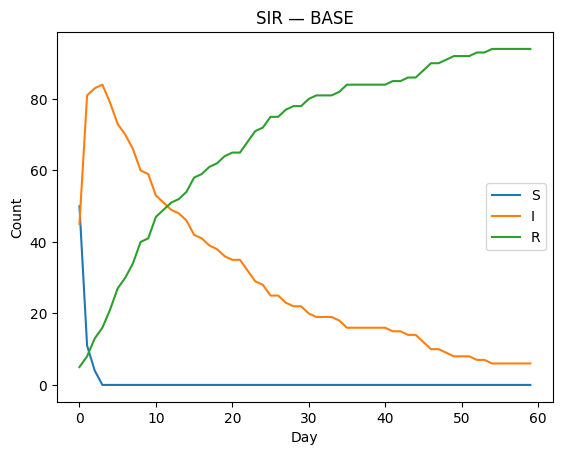

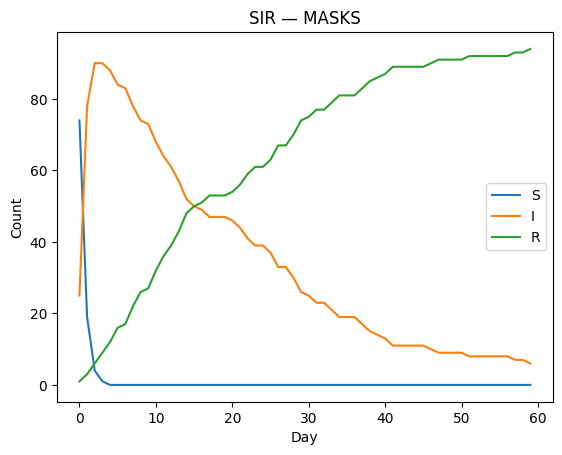

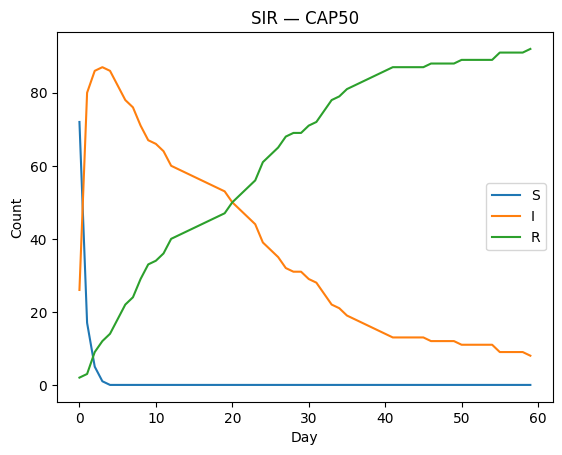

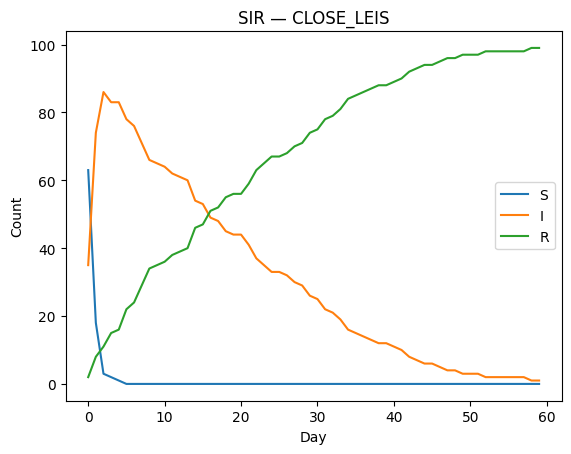

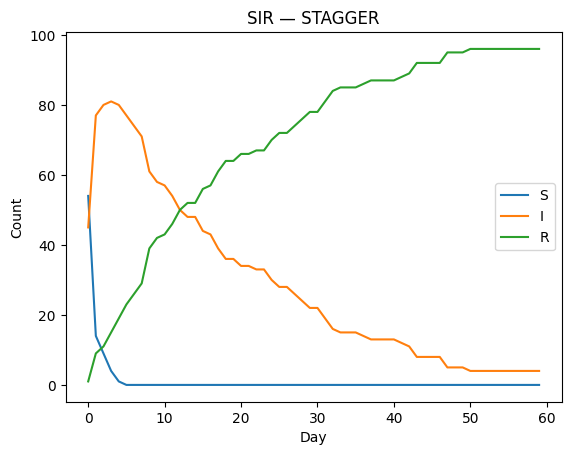

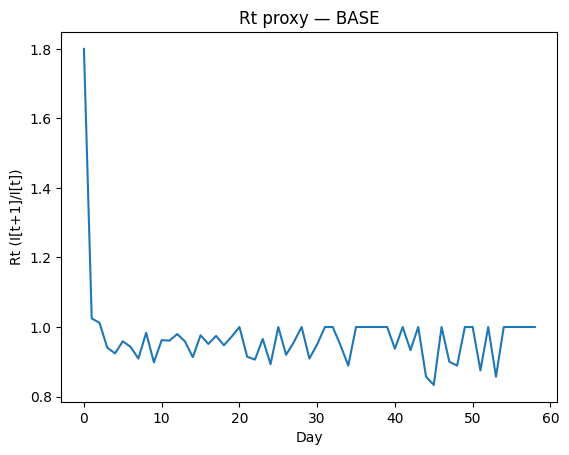

In [ ]:
import matplotlib.pyplot as plt

def plot_series(label, series):
    S = [s['S'] for s in series]
    I = [s['I'] for s in series]
    R = [s['R'] for s in series]
    plt.figure()
    plt.plot(S, label='S')
    plt.plot(I, label='I')
    plt.plot(R, label='R')
    plt.title(f'SIR — {label}')
    plt.xlabel('Day')
    plt.ylabel('Count')
    plt.legend()
    plt.show()

for name, ser in [('BASE',series_BASE),('MASKS',series_MASKS),('CAP50',series_CAP50),('CLOSE_LEIS',series_CLOSE),('STAGGER',series_STAG)]:
    plot_series(name, ser)

Rt = rt_proxy(series_BASE)
plt.figure()
plt.plot(Rt)
plt.title('Rt proxy — BASE')
plt.xlabel('Day')
plt.ylabel('Rt (I[t+1]/I[t])')
plt.show()

## 7) Slices & parity (by archetype)

In [ ]:
from typing import List

def burden_by_archetype(agents_snapshot: List[Agent]):
    by_arch = {'worker':0,'student':0,'retiree':0}
    counts = {'worker':0,'student':0,'retiree':0}
    for a in agents_snapshot:
        counts[a.archetype]+=1
        if a.recovered:
            by_arch[a.archetype]+=1
    for k in by_arch:
        if counts[k]>0:
            by_arch[k] = by_arch[k]/counts[k]
    return by_arch

def run_sim_return_agents(policy: Policy, params: SimParams):
    agents = [Agent(id=a.id, archetype=a.archetype, home=a.home, work_or_school=a.work_or_school, compliance=a.compliance, infected=a.infected, recovered=a.recovered) for a in AGENTS]
    for day in range(params.days):
        day_sched = build_day_schedules(agents, day, policy)
        run_day(agents, day_sched, policy, params)
    return agents

agents_end = run_sim_return_agents(BASE, PARAMS)
by_arch = burden_by_archetype(agents_end)
by_arch

{'worker': 0.975, 'student': 0.925, 'retiree': 0.85}

## 8) Sensitivity (beta sweep)

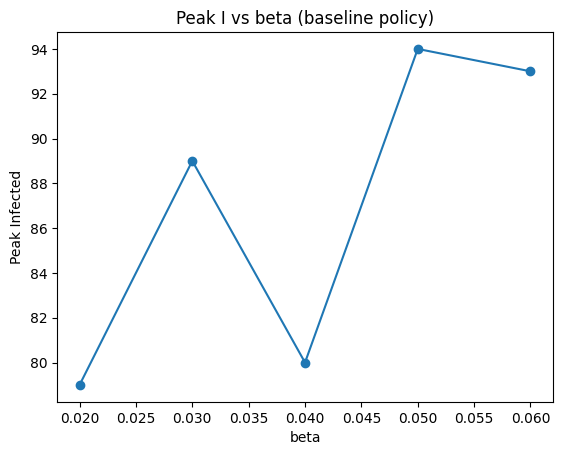

In [ ]:
betas = [0.02, 0.03, 0.04, 0.05, 0.06]
peaks = []
for b in betas:
    p = SimParams(beta=b, gamma=PARAMS.gamma, mask_effect=PARAMS.mask_effect, seed_infected=PARAMS.seed_infected, days=PARAMS.days)
    s = run_sim(BASE, p)
    peaks.append(summary_metrics(s)['peak_I'])

import matplotlib.pyplot as plt
plt.figure()
plt.plot(betas, peaks, marker='o')
plt.title('Peak I vs beta (baseline policy)')
plt.xlabel('beta')
plt.ylabel('Peak Infected')
plt.show()

## 9) Export CSVs

In [ ]:
def export_series(name, series):
    path = EXPORT_DIR / f'{name}_series.csv'
    with open(path, 'w', newline='') as f:
        w = csv.writer(f)
        w.writerow(['day','S','I','R'])
        for i, s in enumerate(series):
            w.writerow([i, s['S'], s['I'], s['R']])
    return path

paths = [export_series('BASE', series_BASE), export_series('MASKS', series_MASKS), export_series('CAP50', series_CAP50), export_series('CLOSE_LEIS', series_CLOSE), export_series('STAGGER', series_STAG)]
[p.as_posix() for p in paths]

['/content/human_agentic_runs/20260111_161118/exports/BASE_series.csv',
 '/content/human_agentic_runs/20260111_161118/exports/MASKS_series.csv',
 '/content/human_agentic_runs/20260111_161118/exports/CAP50_series.csv',
 '/content/human_agentic_runs/20260111_161118/exports/CLOSE_LEIS_series.csv',
 '/content/human_agentic_runs/20260111_161118/exports/STAGGER_series.csv']

## 10) Next steps (LLM planners, calibration, dashboards)

- Swap rule-based schedules with an LLM planner (allow-listed tools, budget caps).
- Add real POI/mobility feeds; calibrate β to match target R0.
- Build a small dashboard (widgets) for scenario toggles.
- Extend parity slices (household size, income proxy).
- Add model card export (assumptions, limits, metrics).



This section adds a reusable **compliance layer** that:

1. Calls an LLM to determine **which internal policy set(s)** apply to a given request.
2. Uses the **Moderation API** to flag unsafe content.
3. Produces a structured **ALLOW / BLOCK / REDACT / ESCALATE** decision you can enforce in your pipeline.

> Notes
> - Uses **Structured Outputs** (`client.responses.parse`) for robust JSON-schema outputs.  
> - Uses **omni-moderation-latest** for moderation.


In [ ]:
# If needed (run once per environment):
%pip install --upgrade openai pydantic --quiet


In [ ]:
import os
import hashlib
from typing import Optional, Literal, List

from openai import OpenAI
from pydantic import BaseModel, Field

# --- Configure your API key ---
# In most environments, export this in your shell instead:
#   export OPENAI_API_KEY="..."
# Or set it here (not recommended for shared notebooks):
# os.environ["OPENAI_API_KEY"] = "sk-..."

# Try to get GL key from Colab, else env var
GL_KEY = None
try:
    from google.colab import userdata  # type: ignore
    GL_KEY = userdata.get("openAI")
except Exception:
    GL_KEY = os.getenv("openAI")

MODE = "ONLINE"
API_BASE = "https://api.openai.com/v1" #Change to great learning API Base
MODEL_ID = "gpt-4o-mini"

client = OpenAI(base_url=API_BASE,
    api_key=GL_KEY)

def safety_id(raw_user_identifier: str) -> str:
    """Hash user/session identifiers before sending to OpenAI."""  # best practice
    return hashlib.sha256(raw_user_identifier.encode("utf-8")).hexdigest()


In [ ]:
# These contain the policy guardrails for what types of simulations you
# want to permit to be considered

POLICY_PACKS = {
    "general_research": {
        "title": "General Research Policy",
        "text": """Follow ethical research norms. Do not provide instructions for wrongdoing.
If content includes personal data, require redaction before storage or sharing.
If content includes self-harm, violence, or hate, escalate to a human reviewer.""",
    },
    "human_subjects": {
        "title": "Human Subjects / IRB-Like Guardrails",
        "text": """No collection or inference of sensitive personal attributes without consent.
Avoid manipulating participants. Ensure transparency and opt-out where applicable.""",
    },
}

# You can choose which policy packs are relevant for a given notebook/project:
DEFAULT_POLICY_KEYS = ["general_research", "human_subjects"]


In [ ]:
from pydantic import BaseModel, Field
from pydantic import ConfigDict
from typing import Optional, Literal, List


class ClosuresSpec(BaseModel):
    model_config = ConfigDict(extra="forbid")
    leisure: Optional[bool] = None
    schools: Optional[bool] = None
    workplaces: Optional[bool] = None

class PolicySpec(BaseModel):
    model_config = ConfigDict(extra="forbid")
    masks: Optional[bool] = None
    capacity_limit: Optional[float] = None
    closures: Optional[ClosuresSpec] = None
    stagger_work: Optional[bool] = None

class ParamsSpec(BaseModel):
    model_config = ConfigDict(extra="forbid")
    beta: Optional[float] = None
    gamma: Optional[float] = None
    mask_effect: Optional[float] = None
    seed_infected: Optional[int] = None
    days: Optional[int] = None

class ScenarioSpec(BaseModel):
    model_config = ConfigDict(extra="forbid")
    name: str = Field(..., description="Scenario label, e.g., BASE, MASKS, CAP50, CLOSE_LEIS, STAGGER")
    policy: Optional[PolicySpec] = None
    params: Optional[ParamsSpec] = None
    seed_override: Optional[int] = None

class RerunPlan(BaseModel):
    model_config = ConfigDict(extra="forbid")
    should_rerun: bool = Field(False, description="Whether to rerun simulations based on compliance/policy.")
    reason: Optional[str] = None
    scenarios: List[ScenarioSpec] = Field(default_factory=list)

class ComplianceDecision(BaseModel):
    model_config = ConfigDict(extra="forbid")
    decision: Literal["ALLOW", "BLOCK", "REDACT", "ESCALATE"] = Field(
        ..., description="The compliance decision."
    )
    rationale: str = Field(..., description="Brief explanation for the decision.")
    applicable_policies: List[str] = Field(
        default_factory=list, description="Keys of policies that apply."
    )
    redactions: List[str] = Field(
        default_factory=list,
        description="If REDACT, list items/fields to remove or mask.",
    )
    safe_alternative: Optional[str] = Field(
        default=None,
        description="If BLOCK, provide a safe alternative phrasing or a narrower request.",
    )
    rerun_plan: Optional[RerunPlan] = Field(
        default=None,
        description="If provided, a machine-readable plan for rerunning earlier agent-based simulations."
    )

class ComplianceEngine:
    def __init__(
        self,
        *,
        client: OpenAI,
        policy_keys: List[str] = None,
        policy_packs: dict = None,
        model: str = "gpt-4o-mini",
        moderation_model: str = "omni-moderation-latest",
        reviewer_model: str = "gpt-4o-mini",
    ):
        self.client = client
        self.policy_packs = policy_packs or POLICY_PACKS
        self.policy_keys = policy_keys or DEFAULT_POLICY_KEYS
        self.model = model
        self.reviewer_model = reviewer_model
        self.moderation_model = moderation_model

    def _policies_text(self) -> str:
        chunks = []
        for k in self.policy_keys:
            pack = self.policy_packs[k]
            chunks.append(f"[{k}] {pack['title']}\n{pack['text']}")
        return "\n\n".join(chunks)

    def _moderation_flags(self, content: str) -> dict:
        mod = self.client.moderations.create(
            model=self.moderation_model,
            input=content,
        )
        r = mod.results[0]
        return {
            "flagged": r.flagged,
            "categories": getattr(r, "categories", None),
            "category_scores": getattr(r, "category_scores", None),
        }

    def decide(
        self,
        *,
        user_request: str,
        context: str = "",
        user_identifier: str = "demo_user",
    ) -> ComplianceDecision:
        """Return a structured compliance decision for a request."""
        mods = self._moderation_flags(user_request)

        system = f"""You are a compliance gate for this research notebook.

You MUST output JSON that matches the provided schema.

You have:
1) Policy packs:
{self._policies_text()}

2) Moderation signal:
{mods}

This notebook contains an agent-based simulation function:
- run_sim(policy: Policy, params: SimParams, seed_override: Optional[int]=None)

The key tunable policy fields are:
- masks: bool
- capacity_limit: float
- closures: dict[str,bool]  (e.g., {{'retail': True, 'park': True}})
- stagger_work: bool

The key tunable SimParams fields are:
- beta, gamma, mask_effect, seed_infected, days

If the user's request implies rerunning simulations (e.g., changing policy knobs/params, asking for new scenario comparisons, sensitivity sweeps),
populate rerun_plan with:
- rerun=True
- scenarios (optional): any of [BASE, MASKS, CAP50, CLOSE_LEIS, STAGGER]
- policy/params overrides consistent with PolicySpec/SimParamsSpec
- seed_override (optional)

Decide whether to ALLOW, BLOCK, REDACT, or ESCALATE:
- ALLOW: safe and compliant.
- REDACT: allowed after removing/masking listed fields.
- ESCALATE: ambiguous/high-risk; needs human review.
- BLOCK: disallowed; provide safe_alternative.

Be concise and specific about policy triggers.
"""

        resp = self.client.responses.parse(
            model=self.model,
            input=[
                {"role": "system", "content": system},
                {"role": "user", "content": f"Context: {context}\n\nRequest: {user_request}"},
            ],
            text_format=ComplianceDecision,
            safety_identifier=safety_id(user_identifier),
        )
        return resp.output_parsed

    def enforce(
        self,
        *,
        user_request: str,
        context: str = "",
        user_identifier: str = "demo_user",
    ) -> str:
        """Either returns the request (allowed/redacted) or raises."""
        decision = self.decide(
            user_request=user_request,
            context=context,
            user_identifier=user_identifier,
        )

        if decision.decision == "ALLOW":
            return user_request

        if decision.decision == "REDACT":
            redacted = user_request
            for item in decision.redactions:
                if item:
                    redacted = redacted.replace(item, "[REDACTED]")
            return redacted

        if decision.decision == "ESCALATE":
            raise RuntimeError(
                f"Compliance ESCALATE: {decision.rationale}\n"
                f"Applicable policies: {decision.applicable_policies}"
            )

        raise ValueError(
            f"Compliance BLOCK: {decision.rationale}\n"
            f"Safe alternative: {decision.safe_alternative}"
        )


In [ ]:
# Helpers to convert ComplianceDecision outputs into actual simulation runs

from dataclasses import replace
import random

def _policy_to_dict(policy: Policy) -> dict:
    return {
        "masks": policy.masks,
        "capacity_limit": policy.capacity_limit,
        "closures": dict(policy.closures or {}),
        "stagger_work": policy.stagger_work,
    }

def build_policy_from_spec(base_policy: Policy, spec: PolicySpec | None) -> Policy:
    """Create a Policy by applying a PolicySpec override onto base_policy."""
    if spec is None:
        return base_policy

    closures = dict(getattr(base_policy, "closures", {}) or {})
    if spec.closures is not None:
        # Only override specified closure keys; leave others as-is.
        if spec.closures.leisure is not None:
            closures["leisure"] = spec.closures.leisure
        if spec.closures.schools is not None:
            closures["schools"] = spec.closures.schools
        if spec.closures.workplaces is not None:
            closures["workplaces"] = spec.closures.workplaces

    return replace(
        base_policy,
        masks=base_policy.masks if spec.masks is None else spec.masks,
        capacity_limit=base_policy.capacity_limit if spec.capacity_limit is None else spec.capacity_limit,
        closures=closures,
        stagger_work=base_policy.stagger_work if spec.stagger_work is None else spec.stagger_work,
    )

def build_params_from_spec(base_params: SimParams, spec: ParamsSpec | None) -> SimParams:
    """Create SimParams by applying ParamsSpec override onto base_params."""
    if spec is None:
        return base_params

    return replace(
        base_params,
        beta=base_params.beta if spec.beta is None else spec.beta,
        gamma=base_params.gamma if spec.gamma is None else spec.gamma,
        mask_effect=base_params.mask_effect if spec.mask_effect is None else spec.mask_effect,
        seed_infected=base_params.seed_infected if spec.seed_infected is None else spec.seed_infected,
        days=base_params.days if spec.days is None else spec.days,
    )

def rerun_from_decision(
    decision: ComplianceDecision,
    *,
    base_policy: Policy,
    base_params: SimParams,
    seed_default: int = 0,
) -> dict:
    """Execute run_sim(...) for each scenario in decision.rerun_plan and return {name: series}."""
    if not decision.rerun_plan or not decision.rerun_plan.should_rerun:
        return {}

    results = {}
    for sc in decision.rerun_plan.scenarios:
        # Build policy + params for this scenario
        pol = build_policy_from_spec(base_policy, sc.policy)
        par = build_params_from_spec(base_params, sc.params)

        # Reproducibility: seed RNG before each run
        random.seed(seed_default if sc.seed_override is None else sc.seed_override)

        results[sc.name] = run_sim(pol, par)

    return results


In [ ]:
# Ask for a change in simulation output that should trigger a rerun plan.

engine = ComplianceEngine(client=client)


decision = engine.decide(
    user_request="Rerun the simulation comparing BASE vs MASKS with beta=0.03 for 90 days, and use a fixed seed for reproducibility.",
    context="Notebook run_sim() is available; please return a rerun_plan compatible with it.",
    user_identifier="Session-001",
)
decision


ComplianceDecision(decision='ALLOW', rationale='The request to rerun the simulation is compliant with existing policies and does not raise any ethical concerns.', applicable_policies=['general_research', 'human_subjects'], redactions=[], safe_alternative=None, rerun_plan=RerunPlan(should_rerun=True, reason=None, scenarios=[ScenarioSpec(name='BASE', policy=None, params=ParamsSpec(beta=0.03, gamma=None, mask_effect=None, seed_infected=None, days=90), seed_override=12345), ScenarioSpec(name='MASKS', policy=PolicySpec(masks=True, capacity_limit=None, closures=None, stagger_work=None), params=ParamsSpec(beta=0.03, gamma=None, mask_effect=None, seed_infected=None, days=90), seed_override=12345)]))

In [ ]:
# If compliant, execute the rerun plan and compute summary metrics.
if decision.decision in ("ALLOW", "REDACT") and decision.rerun_plan and decision.rerun_plan.should_rerun:
    rerun_results = rerun_from_decision(decision, base_policy=BASE_POLICY, base_params=PARAMS)

    summaries = {name: summary_metrics(series) for name, series in rerun_results.items()}
    print(summaries)
else:
    print("No rerun requested or not allowed:", decision.decision)

{'BASE': {'peak_I': 82, 'attack_rate': 0.99}, 'MASKS': {'peak_I': 84, 'attack_rate': 1.0}}


## Conclusions

In this lab, you built intuition for how agents can be used to represent individual behavior and how policy choices can shape epidemic outcomes. By simulating agents moving through shared locations, we obsuerved how small changes in assumptions—like masking, capacity limits, or schedules—can lead to large differences in system-level behavior.

We also explored how Agentic AI Agents can act as decision and compliance layers, translating high-level rules into concrete actions such as rerunning simulations with modified parameters. This illustrates an important idea: ***modern modeling systems can combine simulation, reasoning, and governance in a single workflow.***

Together, these tools provide a foundation for experimenting responsibly with complex human-centered systems, while keeping assumptions, constraints, and outcomes explicit and reproducible.